# SkinGuard XAI Inference Notebook

This notebook is used for prediction only.

The training notebook created and saved the model.  
This inference notebook loads the trained model and predicts the skin lesion class from a new image.

## Workflow

1. Load trained model
2. Load class names
3. Select a skin lesion image
4. Preprocess the image
5. Predict lesion class
6. Show confidence score
7. Display medical disclaimer

In [1]:
import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

print("TensorFlow Version:", tf.__version__)

2026-06-28 16:24:38.266538: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782663878.504198      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782663878.567068      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782663879.109439      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782663879.109495      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782663879.109498      16 computation_placer.cc:177] computation placer alr

TensorFlow Version: 2.19.0


## Step 1: Locate Model Files

The trained model and class names were saved from the training notebook.

For inference, we need:

- `SkinGuard_XAI_Image_Model.keras`
- `class_names.json`

The image-only model is easier for deployment because it only needs a skin image as input.

In [2]:
BASE_PATH = "/kaggle/input"

for dirname, _, filenames in os.walk(BASE_PATH):
    for filename in filenames:
        if filename.endswith(".keras") or filename.endswith(".json"):
            print(os.path.join(dirname, filename))

/kaggle/input/notebooks/rinvijaman/skinguard-xai/__output__.json
/kaggle/input/notebooks/rinvijaman/skinguard-xai/model/SkinGuard_XAI_Image_Model.keras
/kaggle/input/notebooks/rinvijaman/skinguard-xai/model/SkinGuard_XAI_Metadata_Fusion_Model.keras
/kaggle/input/notebooks/rinvijaman/skinguard-xai/model/metadata_columns.json
/kaggle/input/notebooks/rinvijaman/skinguard-xai/model/class_names.json


In [3]:
MODEL_PATH = "/kaggle/input/notebooks/rinvijaman/skinguard-xai/model/SkinGuard_XAI_Image_Model.keras"

CLASS_NAMES_PATH = "/kaggle/input/notebooks/rinvijaman/skinguard-xai/model/class_names.json"

## Step 2: Load the Trained Model

Now we load the trained MobileNetV2 image-only model.

This model accepts one image and predicts one of the HAM10000 lesion classes.

In [4]:
model = tf.keras.models.load_model(MODEL_PATH)

with open(CLASS_NAMES_PATH, "r") as f:
    class_names = json.load(f)

print("✅ Model loaded successfully!")

print("\nClasses:")
for i, cls in enumerate(class_names):
    print(f"{i}: {cls}")

2026-06-28 16:25:14.972681: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


✅ Model loaded successfully!

Classes:
0: akiec
1: bcc
2: bkl
3: df
4: mel
5: nv
6: vasc


## Step 3: Define Class Descriptions

HAM10000 uses short labels such as `mel`, `nv`, and `bcc`.

To make the prediction easier to understand, we map each short label to its full medical name.

In [5]:
class_descriptions = {
    "akiec": "Actinic keratoses and intraepithelial carcinoma",
    "bcc": "Basal cell carcinoma",
    "bkl": "Benign keratosis-like lesions",
    "df": "Dermatofibroma",
    "mel": "Melanoma",
    "nv": "Melanocytic nevi",
    "vasc": "Vascular lesions"
}

for label in class_names:
    print(label, ":", class_descriptions.get(label, "Unknown"))

akiec : Actinic keratoses and intraepithelial carcinoma
bcc : Basal cell carcinoma
bkl : Benign keratosis-like lesions
df : Dermatofibroma
mel : Melanoma
nv : Melanocytic nevi
vasc : Vascular lesions


## Step 4: Image Preprocessing Function

The uploaded image must be prepared in the same way as the training images.

Preprocessing steps:

1. Read image
2. Convert BGR to RGB
3. Resize to 224 × 224
4. Convert image to batch format
5. Apply MobileNetV2 preprocessing

In [6]:
IMG_SIZE = 224

def preprocess_skin_image(image_path):
    image = cv2.imread(image_path)

    if image is None:
        raise ValueError("Image not found. Please check the image path.")

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    resized_image = cv2.resize(
        image,
        (IMG_SIZE, IMG_SIZE)
    )

    image_array = np.expand_dims(
        resized_image.astype("float32"),
        axis=0
    )

    image_array = preprocess_input(image_array)

    return image, resized_image, image_array

## Step 5: Prediction Function

This function takes an image path and returns:

- Predicted class
- Full medical name
- Confidence score
- Top 3 predictions

In [7]:
def predict_skin_lesion(image_path):
    original_image, resized_image, processed_image = preprocess_skin_image(image_path)

    predictions = model.predict(processed_image)

    predicted_index = np.argmax(predictions[0])

    predicted_label = class_names[predicted_index]

    predicted_name = class_descriptions.get(
        predicted_label,
        predicted_label
    )

    confidence = predictions[0][predicted_index]

    top_3_indices = np.argsort(predictions[0])[-3:][::-1]

    top_3_predictions = []

    for index in top_3_indices:
        label = class_names[index]
        name = class_descriptions.get(label, label)
        score = predictions[0][index]

        top_3_predictions.append(
            {
                "Label": label,
                "Class Name": name,
                "Confidence": score
            }
        )

    return original_image, predicted_label, predicted_name, confidence, top_3_predictions

## Step 6: Select a Test Image

For testing, use any skin lesion image.

You can use:

- An image from the HAM10000 dataset
- A manually uploaded image
- A sample image saved in the project folder

In [8]:
HAM10000_PATH = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000"

sample_images = []

for dirname, _, filenames in os.walk(HAM10000_PATH):
    for filename in filenames:
        if filename.endswith(".jpg"):
            sample_images.append(os.path.join(dirname, filename))

print("Number of sample images found:", len(sample_images))
print("First image:", sample_images[0])

Number of sample images found: 20030
First image: /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028933.jpg


In [9]:
test_image_path = sample_images[0]

print("Test Image Path:", test_image_path)

Test Image Path: /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028933.jpg


## Step 7: Run Prediction

Now we use the trained model to predict the lesion class of the selected image.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


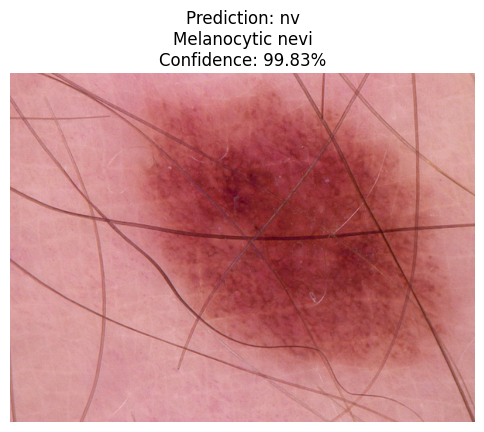

In [10]:
original_image, predicted_label, predicted_name, confidence, top_3_predictions = predict_skin_lesion(
    test_image_path
)

plt.figure(figsize=(6, 6))

plt.imshow(original_image)

plt.title(
    f"Prediction: {predicted_label}\n"
    f"{predicted_name}\n"
    f"Confidence: {confidence:.2%}"
)

plt.axis("off")

plt.show()

## Step 8: Show Top 3 Predictions

Instead of only showing one prediction, it is better to display the top 3 predictions.

This helps users understand model uncertainty.

In [11]:
for i, prediction in enumerate(top_3_predictions, start=1):
    print(f"Top {i}")
    print("Label:", prediction["Label"])
    print("Class Name:", prediction["Class Name"])
    print("Confidence:", f"{prediction['Confidence']:.2%}")
    print()

Top 1
Label: nv
Class Name: Melanocytic nevi
Confidence: 99.83%

Top 2
Label: bkl
Class Name: Benign keratosis-like lesions
Confidence: 0.10%

Top 3
Label: mel
Class Name: Melanoma
Confidence: 0.07%



## Step 9: Save Prediction Output

We save the prediction result so it can be added to the project outputs folder.

In [12]:
import pandas as pd

os.makedirs("outputs", exist_ok=True)

prediction_df = pd.DataFrame(top_3_predictions)

prediction_df.to_csv(
    "outputs/inference_prediction.csv",
    index=False
)

prediction_df

,Label,Class Name,Confidence
0,nv,Melanocytic nevi,0.998284
1,bkl,Benign keratosis-like lesions,0.000993
2,mel,Melanoma,0.000705


# Grad-CAM Explainability

Grad-CAM helps us understand which part of the skin lesion image influenced the model prediction.

It creates a heatmap over the image.

Bright or warm regions show the areas that the model focused on most.

## Step 1: Create the Grad-CAM Function

The Grad-CAM algorithm calculates the gradients flowing into the last convolutional layer of the neural network.

These gradients indicate **which image features were most important** for predicting the selected class.

The output is a heatmap where:

- 🔵 Blue regions contribute very little.
- 🟢 Green regions contribute moderately.
- 🔴 Red regions contribute the most.

The brighter the color, the more attention the model paid to that region.

In [13]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)

    heatmap = heatmap / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

## Step 2: Locate the Last Convolutional Layer

Grad-CAM requires the output of the **last convolutional layer** because it contains the highest-level visual features learned by the CNN.

Examples of these features include:

- lesion boundaries
- color variation
- texture
- irregular shapes

We first identify the final convolutional layer inside the MobileNetV2 architecture.

In [14]:
for layer in reversed(model.layers):
    if len(layer.output.shape) == 4:
        print("Last convolution layer:", layer.name)
        break

Last convolution layer: mobilenetv2_1.00_224


In [15]:
base_model = None

for layer in model.layers:
    if "mobilenet" in layer.name.lower():
        base_model = layer
        print("Found base model:", layer.name)

for layer in reversed(base_model.layers):
    if len(layer.output.shape) == 4:
        last_conv_layer_name = layer.name
        print("Last conv layer inside MobileNetV2:", last_conv_layer_name)
        break

Found base model: mobilenetv2_1.00_224
Last conv layer inside MobileNetV2: out_relu


## Step 3: Build the Grad-CAM Model

Our trained model contains MobileNetV2 as a backbone.

This step creates a new model that outputs:

1. Feature maps from the last convolutional layer.
2. Final prediction probabilities.

These outputs allow us to calculate the Grad-CAM heatmap.

In [16]:
def make_gradcam_heatmap_mobilenet(img_array, model, base_model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        inputs=base_model.input,
        outputs=[
            base_model.get_layer(last_conv_layer_name).output,
            base_model.output
        ]
    )

    classifier_input = tf.keras.Input(shape=base_model.output.shape[1:])
    x = classifier_input

    start_classification = False

    for layer in model.layers:
        if layer.name == base_model.name:
            start_classification = True
            continue

        if start_classification:
            x = layer(x)

    classifier_model = tf.keras.Model(
        classifier_input,
        x
    )

    with tf.GradientTape() as tape:
        preprocessed_image = img_array

        conv_outputs, base_output = grad_model(preprocessed_image)

        predictions = classifier_model(base_output)

        predicted_index = tf.argmax(predictions[0])

        class_channel = predictions[:, predicted_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)

    heatmap = heatmap / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

## Step 4: Generate the Heatmap

Now we pass a skin lesion image into the model.

The model predicts the lesion class while Grad-CAM computes which image regions contributed most to that prediction.

The resulting heatmap is normalized so that brighter areas represent stronger influence on the prediction.

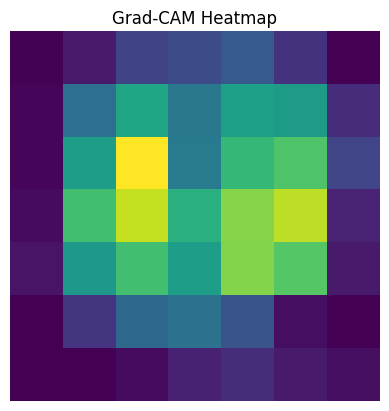

In [17]:
original_image, resized_image, processed_image = preprocess_skin_image(test_image_path)

heatmap = make_gradcam_heatmap_mobilenet(
    processed_image,
    model,
    base_model,
    last_conv_layer_name
)

plt.imshow(heatmap)
plt.title("Grad-CAM Heatmap")
plt.axis("off")
plt.show()

## Step 5: Overlay the Heatmap

Although the heatmap shows important regions, it is easier to understand when placed on top of the original image.

This overlay combines:

- Original dermoscopic image
- Grad-CAM heatmap

This allows us to visually inspect whether the model focused on clinically relevant lesion regions.

In [18]:
def overlay_gradcam(original_image, heatmap, alpha=0.45):
    heatmap_resized = cv2.resize(
        heatmap,
        (original_image.shape[1], original_image.shape[0]),
        interpolation=cv2.INTER_CUBIC
    )

    heatmap_uint8 = np.uint8(255 * heatmap_resized)

    heatmap_color = cv2.applyColorMap(
        heatmap_uint8,
        cv2.COLORMAP_JET
    )

    heatmap_color = cv2.cvtColor(
        heatmap_color,
        cv2.COLOR_BGR2RGB
    )

    overlay = cv2.addWeighted(
        original_image,
        1 - alpha,
        heatmap_color,
        alpha,
        0
    )

    return heatmap_color, overlay

In [19]:
heatmap_color, overlay_image = overlay_gradcam(
    original_image,
    heatmap
)

## Step 6: Visualize the Results

We display three images side by side:

1. Original skin lesion image
2. Grad-CAM heatmap
3. Heatmap overlaid on the original image

This comparison helps us understand the model's attention during prediction.

In [20]:
import pandas as pd

summary = pd.DataFrame({
    "Prediction": [predicted_name],
    "Short Label": [predicted_label],
    "Confidence": [f"{confidence:.2%}"]
})

summary

,Prediction,Short Label,Confidence
0,Melanocytic nevi,nv,99.83%


In [21]:
top3_df = pd.DataFrame(top_3_predictions)

top3_df["Confidence"] = top3_df["Confidence"].apply(
    lambda x: f"{x:.2%}"
)

top3_df

,Label,Class Name,Confidence
0,nv,Melanocytic nevi,99.83%
1,bkl,Benign keratosis-like lesions,0.10%
2,mel,Melanoma,0.07%


In [22]:
if confidence >= 0.95:
    print("Model Confidence: Very High")
elif confidence >= 0.80:
    print("Model Confidence: High")
elif confidence >= 0.60:
    print("Model Confidence: Moderate")
else:
    print("Model Confidence: Low")

Model Confidence: Very High


SkinGuard XAI Prediction
Predicted Class : Melanocytic nevi
Short Label     : nv
Confidence      : 99.83%

Top 3 Predictions
1. Melanocytic nevi (nv) - 99.83%
2. Benign keratosis-like lesions (bkl) - 0.10%
3. Melanoma (mel) - 0.07%


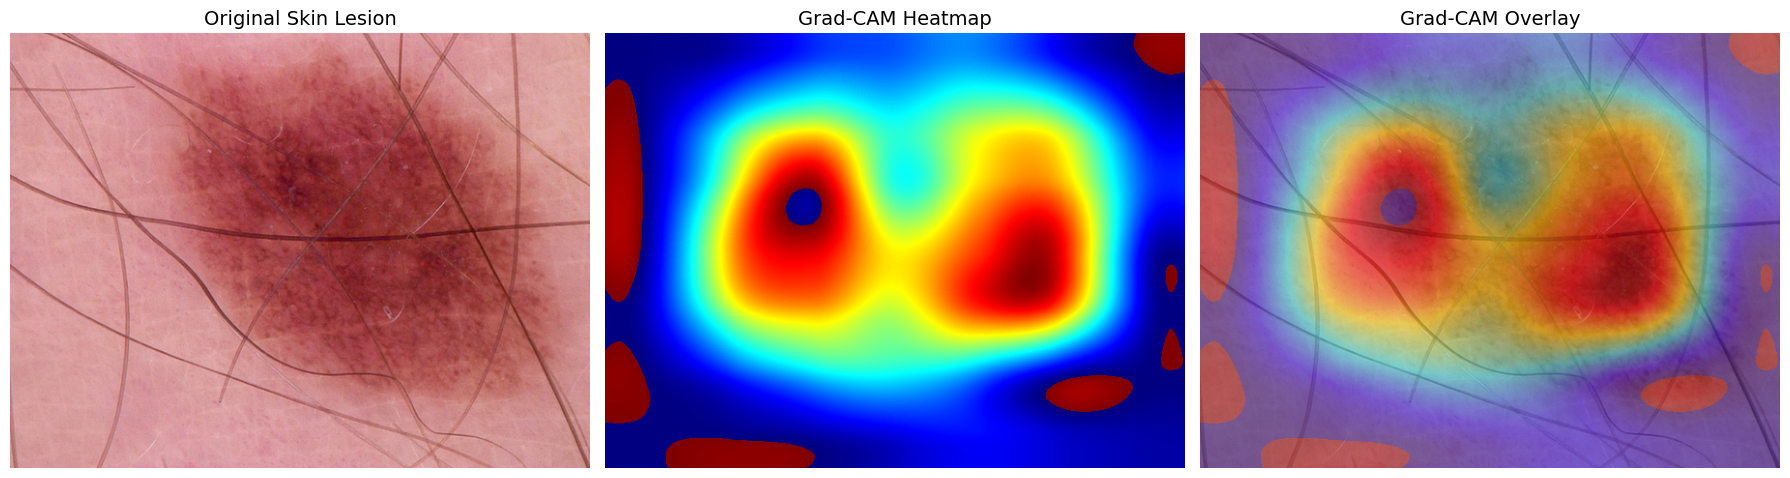

In [23]:
print("=" * 50)
print("SkinGuard XAI Prediction")
print("=" * 50)
print(f"Predicted Class : {predicted_name}")
print(f"Short Label     : {predicted_label}")
print(f"Confidence      : {confidence:.2%}")

print("\nTop 3 Predictions")
for i, pred in enumerate(top_3_predictions, start=1):
    print(
        f"{i}. {pred['Class Name']} "
        f"({pred['Label']}) - "
        f"{pred['Confidence']:.2%}"
    )
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(original_image)
axes[0].set_title("Original Skin Lesion", fontsize=14)
axes[0].axis("off")

axes[1].imshow(heatmap_color)
axes[1].set_title("Grad-CAM Heatmap", fontsize=14)
axes[1].axis("off")

axes[2].imshow(overlay_image)
axes[2].set_title("Grad-CAM Overlay", fontsize=14)
axes[2].axis("off")

plt.tight_layout()

plt.savefig(
    "outputs/gradcam_result.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Step 7: Save the Explainability Result

The Grad-CAM visualization is saved to the project outputs folder.

Saving the result makes it easier to:

- include in research reports
- use in presentations
- upload to GitHub
- compare different model explanations

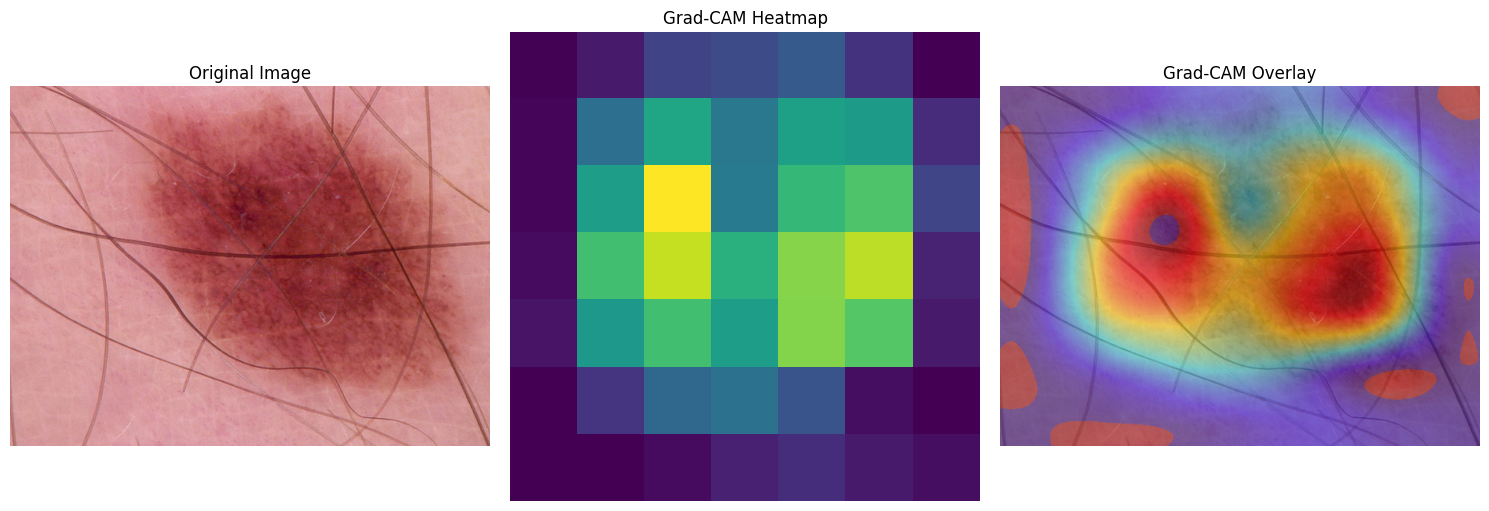

In [24]:
os.makedirs("outputs", exist_ok=True)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(original_image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap)
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay_image)
plt.title("Grad-CAM Overlay")
plt.axis("off")

plt.tight_layout()

plt.savefig(
    "outputs/gradcam_result.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 🎯 Conclusion

In this section, we successfully implemented **Grad-CAM Explainable AI** for our skin lesion classification model.

## What we accomplished

- Loaded the trained MobileNetV2 model
- Predicted the skin lesion class
- Generated a Grad-CAM heatmap
- Visualized the model's attention
- Overlaid the heatmap on the original image
- Saved the explanation for future use

## Why Grad-CAM is important

Unlike traditional image classifiers, Grad-CAM provides a visual explanation of the model's decision-making process.

This increases model transparency and helps researchers verify whether the model is focusing on meaningful lesion characteristics.

Although Grad-CAM does not replace expert medical interpretation, it is a valuable Explainable AI (XAI) technique that improves trust and interpretability in Medical AI systems.

---

## Next Step

The next stage of the project is to build a **Gradio web application**, allowing users to upload a skin lesion image through a browser and receive:

- Predicted lesion class
- Confidence score
- Top-3 predictions
- Grad-CAM visualization

This will transform SkinGuard XAI from a research notebook into a complete end-to-end AI application.

> ⚠️ **Medical Disclaimer**
>
> This prediction is generated by an experimental AI model.
>
> It is intended for educational and research purposes only and should not be considered a clinical diagnosis.